<a href="https://colab.research.google.com/github/gez2code/dermamnist-hybrid-study/blob/main/Kaggle%20Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
# Importing Basic Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

In [15]:
# Importing Dataset
!wget -O Data.npz https://zenodo.org/record/4269852/files/dermamnist.npz?download=1

--2025-12-26 14:32:50--  https://zenodo.org/record/4269852/files/dermamnist.npz?download=1
Resolving zenodo.org (zenodo.org)... 137.138.52.235, 188.185.48.75, 188.185.43.153, ...
Connecting to zenodo.org (zenodo.org)|137.138.52.235|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/4269852/files/dermamnist.npz [following]
--2025-12-26 14:32:51--  https://zenodo.org/records/4269852/files/dermamnist.npz
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 19725078 (19M) [application/octet-stream]
Saving to: ‘Data.npz’

Data.npz            100%[===================>]  18.81M  2.41MB/s    in 9.8s    

2025-12-26 14:33:01 (1.92 MB/s) - ‘Data.npz’ saved [19725078/19725078]



['train_images', 'val_images', 'test_images', 'train_labels', 'val_labels', 'test_labels']
Train Set:      X:(7007, 28, 28, 3) Y:(7007, 1)
Validation Set: X:(1003, 28, 28, 3) Y:(1003, 1)
Test Set :      X:(2005, 28, 28, 3) Y:(2005, 1)


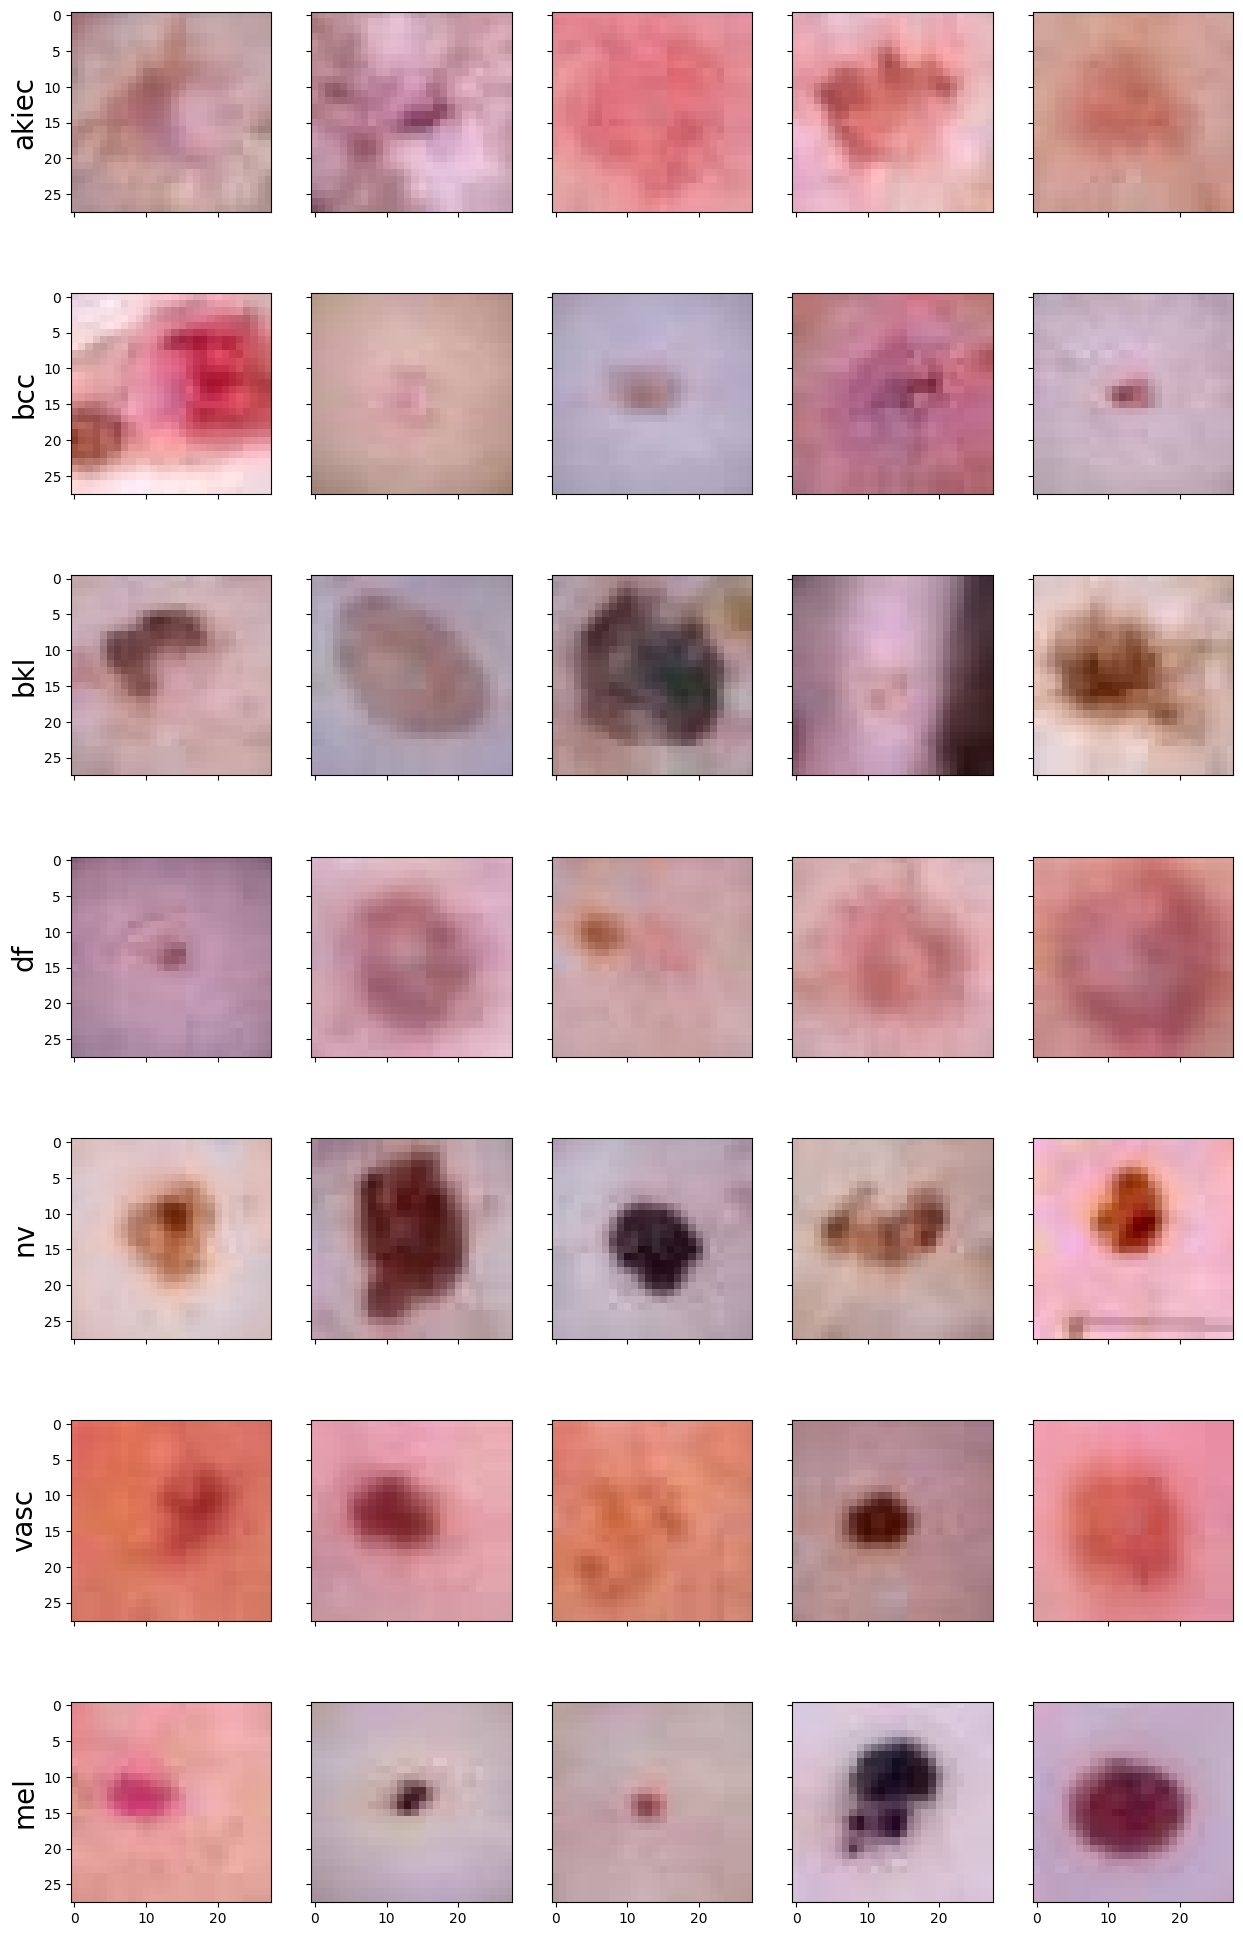

In [48]:
data = np.load('Data.npz')
print(data.files)
print(f'Train Set:      X:%s Y:%s' %(data['train_images'].shape, data['train_labels'].shape))
print(f'Validation Set: X:%s Y:%s' %(data['val_images'].shape, data['val_labels'].shape))
print(f'Test Set :      X:%s Y:%s' %(data['test_images'].shape, data['test_labels'].shape))

X_train = data['train_images']
X_val = data['val_images']
X_test = data['test_images']
X = np.concatenate((X_train, X_val, X_test), axis=0)

y_train = data['train_labels']
y_val = data['val_labels']
y_test = data['test_labels']
y = np.concatenate((y_train, y_val, y_test), axis=0)

labels = ['akiec',
          'bcc',
          'bkl',
          'df',
          'nv',
          'vasc',
          'mel']

lesion_type_dict = {
    'akiec': 'Actinic keratoses',
    'bcc': 'Basal cell carcinoma',
    'bkl': 'Benign keratosis-like lesions ',
    'df': 'Dermatofibroma',
    'nv': 'Melanocytic nevi',
    'vasc': 'Vascular lesions',
    'mel': 'Melanoma'
}

np.unique(y)

num_classes = []
for i in range(len(labels)):
  num_classes.append(len(np.where(y==i)[0]))

pd.DataFrame(num_classes,index=labels)

# Visualizing our data

fig, ax = plt.subplots(7, 5)
fig.set_figheight(25)
fig.set_figwidth(15)
for classes in range (7):
  for i, inx in enumerate(np.where(y==classes)[0][:5]):
    ax[classes,i].imshow(X[inx])
    ax[classes,i].set_ylabel(labels[classes],fontsize = 20.0)
    ax[classes,i].label_outer()

In [52]:
# Data Preprocessing and Augmentation

# Resampling
num_classes = []
for i in range(len(labels)):
  num_classes.append(len(np.where(y_train==i)[0]))

pd.DataFrame(num_classes,index=labels)

from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

os_dict = {0: num_classes[0]*7,
           1: num_classes[1]*5,
           2: 1500,
           3: 2500,
           4: 1500,
           5: num_classes[5],
           6: 1500}
oversample = RandomOverSampler(sampling_strategy=os_dict)
oversampled_X , oversampled_y = oversample.fit_resample(X_train.reshape(X_train.shape[0], -1), y_train)
print('OS_X:%s OS_y:%s' %(oversampled_X.shape, oversampled_y.shape))

us_dict = {0: num_classes[0]*7,
           1: num_classes[1]*5,
           2: 1500,
           3: 2500,
           4: 1500,
           5: 3000,
           6: 1500}

undersample = RandomUnderSampler(sampling_strategy=us_dict)
undersampled_X , undersampled_y = undersample.fit_resample(oversampled_X, oversampled_y)
print('US_X:%s US_y:%s' %(undersampled_X.shape, undersampled_y.shape))
undersampled_y.shape
undersampled_X = undersampled_X.reshape(-1,28,28,3)
num_classes = []
for i in range(len(labels)):
  num_classes.append(len(np.where(undersampled_y==i)[0]))

pd.DataFrame(num_classes,index=labels)

# Making Labels Categorical
from tensorflow.keras.utils import to_categorical

# Reset y_val and y_test to their original (N, 1) form from the loaded data
# This prevents issues if the cell was run multiple times and y_val/y_test were already transformed
y_val_original = data['val_labels']
y_test_original = data['test_labels']

undersampled_y = to_categorical(undersampled_y)
y_val = to_categorical(y_val_original)
y_test = to_categorical(y_test_original)
undersampled_y.shape

# Image Data Generator
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(rescale = 1./255,
                                  rotation_range = 10,
                                  width_shift_range = 0.2,
                                  height_shift_range = 0.2,
                                  shear_range = 0.2,
                                  horizontal_flip = True,
                                  vertical_flip = True,
                                  fill_mode = 'wrap')

batch_size=50
train_data = train_datagen.flow(undersampled_X, undersampled_y, batch_size = batch_size, seed=1)

test_datagen = ImageDataGenerator(rescale = 1./255)
val_data = test_datagen.flow(X_val, y_val, batch_size=batch_size,seed=1)

print(f'Train Set:      X:%s Y:%s' %(train_data.x.shape, train_data.y.shape))
print(f'Validation Set: X:%s Y:%s' %(val_data.x.shape, val_data.y.shape))
print(f'Test Set :      X:%s Y:%s' %(X_test.shape, y_test.shape))

num_classes = []
for i in range(len(labels)):
  num_classes.append(len(np.where(np.argmax(val_data.y, axis=1)==i)[0]))

pd.DataFrame(num_classes,index=labels)

OS_X:(15084, 2352) OS_y:(15084,)
US_X:(13391, 2352) US_y:(13391,)
Train Set:      X:(13391, 28, 28, 3) Y:(13391, 7)
Validation Set: X:(1003, 28, 28, 3) Y:(1003, 7)
Test Set :      X:(2005, 28, 28, 3) Y:(2005, 7)


,0
akiec,33
bcc,52
bkl,110
df,12
nv,111
vasc,671
mel,14


Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


267/267 ━━━━━━━━━━━━━━━━━━━━ 25s 72ms/step - acc: 0.2565 - loss: 1.8457 - val_acc: 0.6130 - val_loss: 1.1595
Epoch 2/30
  1/267 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - acc: 0.5000 - loss: 1.5146

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.5000 - loss: 1.5146 - val_acc: 0.6220 - val_loss: 1.1398
Epoch 3/30
267/267 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - acc: 0.3702 - loss: 1.5900 - val_acc: 0.5220 - val_loss: 1.1929
Epoch 4/30
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.5000 - loss: 1.5249 - val_acc: 0.5410 - val_loss: 1.1856
Epoch 5/30
267/267 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - acc: 0.4329 - loss: 1.4540 - val_acc: 0.5400 - val_loss: 1.2901
Epoch 6/30
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.5000 - loss: 1.1500 - val_acc: 0.5220 - val_loss: 1.3370
Epoch 7/30
267/267 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - acc: 0.4764 - loss: 1.3157 - val_acc: 0.5500 - val_loss: 0.9939
Epoch 8/30
267/267 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.4600 - loss: 1.2279 - val_acc: 0.5400 - val_loss: 1.0323
Epoch 9/30
267/267 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - acc: 0.5000 - loss: 1.2542 - val_acc: 0.5080 - val_loss: 1.2030
Epoch 10/30
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc:

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 28, 28, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 28, 28, 256)    │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 14, 14, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 14, 14, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 7, 7, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 3, 3, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1024)           │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 7)              │         7,175 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,621,847 (51.96 MB)

 Trainable params: 4,540,615 (17.32 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,081,232 (34.64 MB)

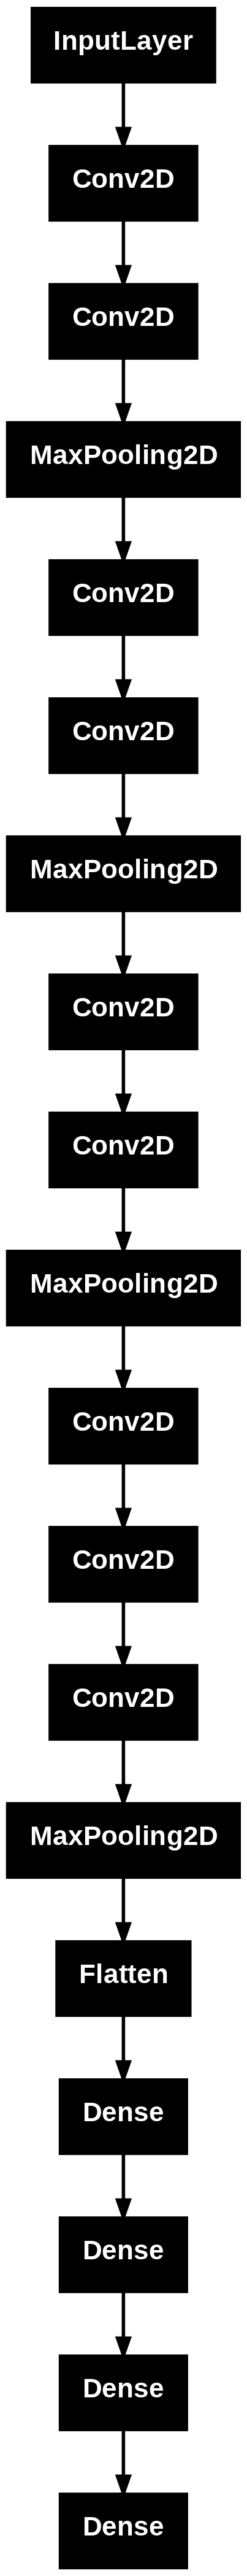

In [51]:
# Model Creation
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPool2D, Flatten

input_layer = Input(shape=(28,28,3))

# convolution block 1
cb11 = Conv2D(filters=256, kernel_size=(3,3), strides=(1,1), padding="same", activation="relu")(input_layer)
cb12 = Conv2D(filters=256, kernel_size=(3,3), strides=(1,1), padding="same", activation="relu")(cb11)
maxpl1 = MaxPool2D((2,2))(cb12)

#convolution block 2
cb21 = Conv2D(filters=256, kernel_size=(3,3), strides=(1,1), padding="same", activation="relu")(maxpl1)
cb22 = Conv2D(filters=256, kernel_size=(3,3), strides=(1,1), padding="same", activation="relu")(cb21)
maxpl2 = MaxPool2D((2,2))(cb22)

#convolution block 3
cb31 = Conv2D(filters=128, kernel_size=(3,3), strides=(1,1), padding="same", activation="relu")(maxpl2)
cb32 = Conv2D(filters=128, kernel_size=(3,3), strides=(1,1), padding="same", activation="relu")(cb31)
maxpl3 = MaxPool2D((2,2))(cb32)

#convolution block 4
cb41 = Conv2D(filters=64, kernel_size=(3,3), strides=(1,1), padding="same", activation="relu")(maxpl3)
cb42 = Conv2D(filters=64, kernel_size=(3,3), strides=(1,1), padding="same", activation="relu")(cb41)
cb43 = Conv2D(filters=64, kernel_size=(3,3), strides=(1,1), padding="same", activation="relu")(cb42)
maxpl4 = MaxPool2D((2,2))(cb43)

# artificial neural network block
flat   = Flatten()(maxpl4)
dense1 = Dense(1024, activation="relu")(flat)
dense2 = Dense(1024, activation="relu")(dense1)
dense3 = Dense(1024, activation="relu")(dense2)
output = Dense(7, activation="softmax")(dense3)
model = Model(inputs=input_layer, outputs=output)


model.compile(optimizer= keras.optimizers.Adam(0.0001, decay=1e-5),
              loss='categorical_crossentropy',
              metrics=['acc'])#keras.metrics.Accuracy())

batch_size = batch_size
epochs = 30
model_history = model.fit(train_data,
                          steps_per_epoch= int(train_data.n/batch_size),
                          epochs=epochs,
                          validation_data=val_data,
                          validation_steps=int(val_data.n/batch_size))

model_history.params

model.summary()

from tensorflow.keras.utils import plot_model
plot_model(model)


63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - acc: 0.6196 - loss: 0.9859


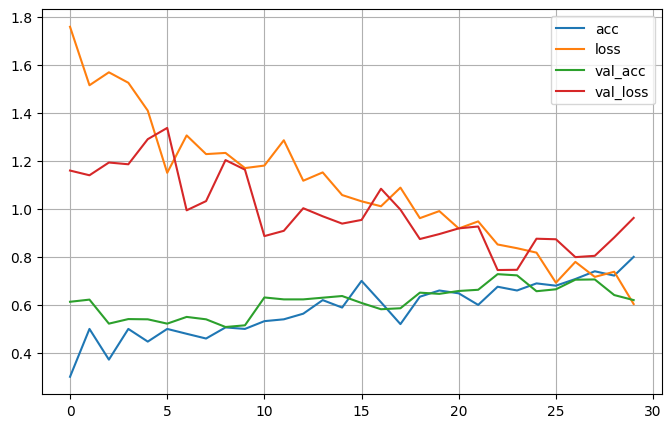

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
              precision    recall  f1-score   support

       akiec       0.33      0.61      0.42        66
         bcc       0.37      0.70      0.49       103
         bkl       0.45      0.53      0.49       220
          df       0.19      0.30      0.24        23
          nv       0.29      0.59      0.39       223
        vasc       0.96      0.63      0.76      1341
         mel       0.39      0.90      0.55        29

    accuracy                           0.61      2005
   macro avg       0.43      0.61      0.48      2005
weighted avg       0.76      0.61      0.65      2005

<Conv2D name=conv2d_46, built=True>
[<Variable path=conv2d_46/kernel, shape=(3, 3, 3, 256), dtype=float32, value=[[[[ 3.62367220e-02  1.70141831e-02  3.65676396e-02 ... -3.46986689e-02
     3.87732461e-02  3.37514281e-02]
   [-5.30413259e-03  4.26737256e-02  3.64962756e-03 ...  1.13569573e-03
    -6.66198088e-03  1.77735370e-02]
   [-1.12037975e-02 -4.97383066e

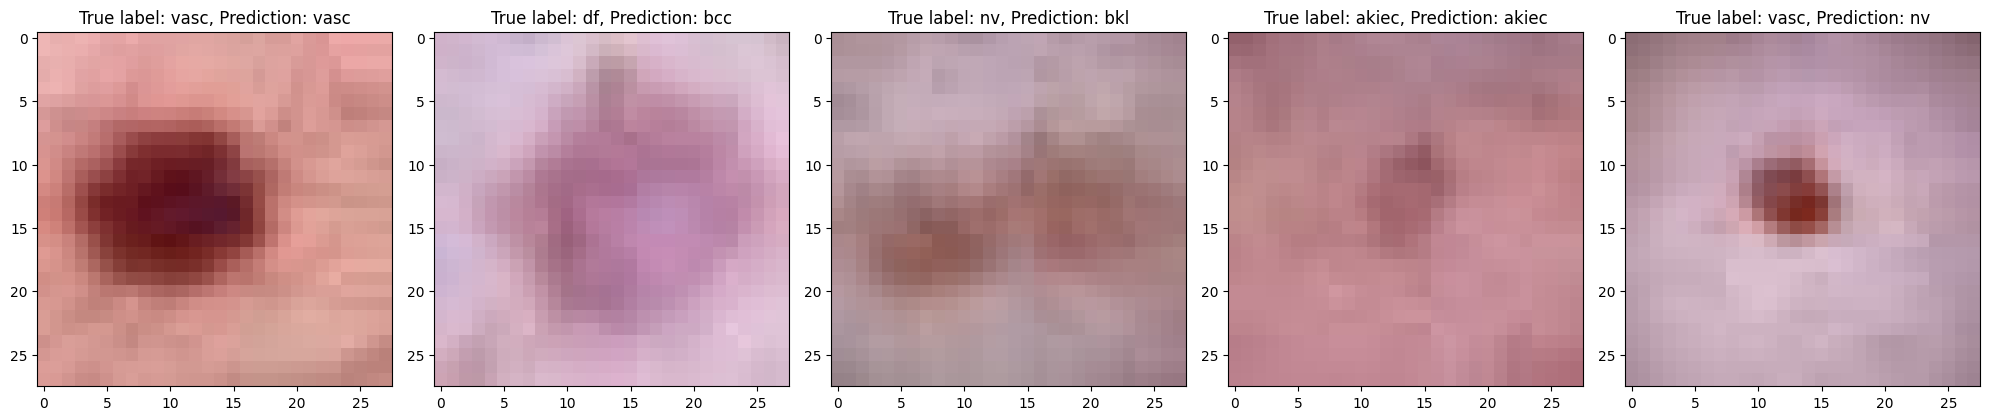

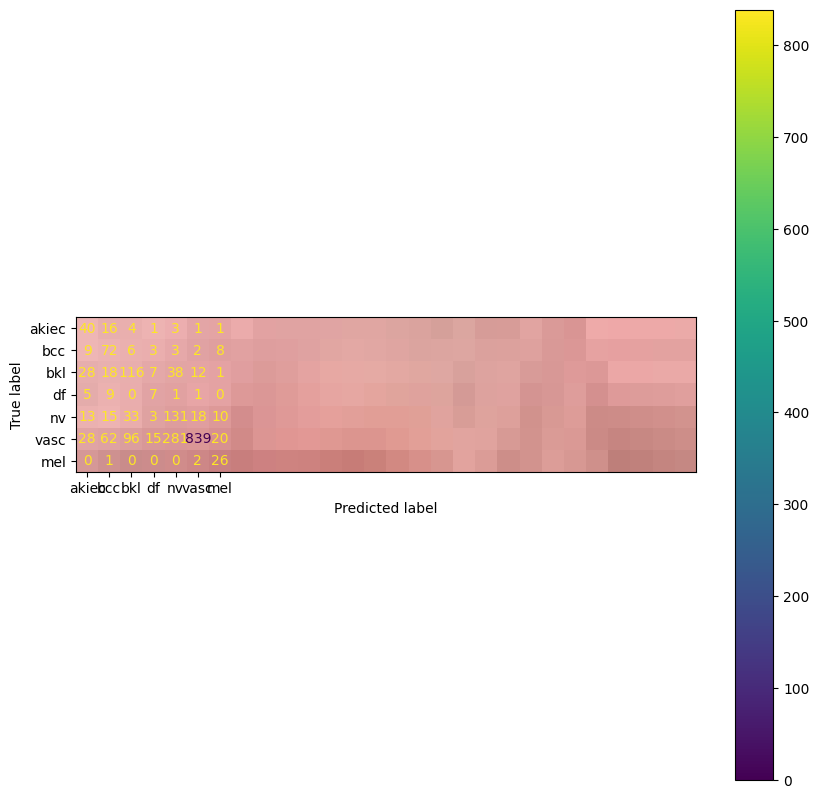

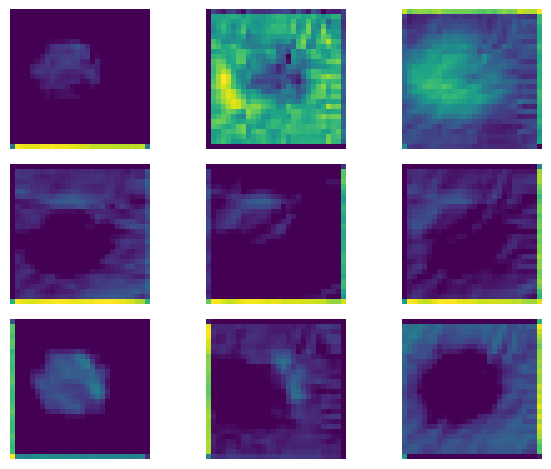

In [53]:
# Model Evaluation

model.evaluate(X_test/255, y_test)

pd.DataFrame(model_history.history).plot(figsize=(8,5))
plt.grid(True)
plt.show()

y_proba = model.predict(X_test/255)
y_proba.round(2)


y_pred = np.argmax(y_proba, axis=-1)
y_pred[:10]

y_pred_name = np.array(labels)[y_pred]
y_pred_name[:10]

plt.figure(figsize=(20,10))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[i])
    plt.title('True label: {}, Prediction: {}'.format(labels[y_test[i].argmax()], y_pred_name[i]))
plt.tight_layout()


from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

y_test_numbers = np.array([y.argmax() for y in y_test])

cm = confusion_matrix(y_test_numbers, y_pred)

cm_display = ConfusionMatrixDisplay(cm,display_labels=labels)
fig, ax = plt.subplots(figsize=(10,10))
cm_display.plot(ax=ax)

print(classification_report(y_test_numbers, y_pred, target_names = labels))


model.layers

first_conv = model.layers[1]
print(first_conv)
print(first_conv.weights)

print('Output Shape of the first Convolution layer: ',first_conv(X_test/255).shape)
print('Number of Testset data:                      ',first_conv(X_test/255).shape[0])
print('Number of first Convolution layer:           ',first_conv(X_test/255).shape[3])

n = 0
plt.imshow(X_test[n])


#first layer output
current_layer_output = first_conv(X_test/255)[n]
print(current_layer_output.shape)
fig, ax = plt.subplots(3, 3)
for i in range(9):
  ax[i//3][i%3].imshow(current_layer_output[:,:,i])
  ax[i//3][i%3].axis('off')
plt.tight_layout()